In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def value_iteration(P, R, discount_factor=0.9, theta=1e-8, max_iter=10000):
    n_states = len(P)
    n_actions = len(P[0])

    V = np.zeros(n_states)

    for i in range(max_iter):
        delta = 0

        V_old = V.copy()

        for s in range(n_states):
            q_values = []

            for a in range(n_actions):
                q_sa = 0

                for s_next in range(n_states):
                    prob = P[s][a][s_next]
                    reward = R[s][a][s_next]

                    q_sa += prob * (reward + discount_factor * V_old[s_next])

                q_values.append(q_sa)

            V[s] = max(q_values)

            delta = max(delta, abs(V[s] - V_old[s]))

        if delta < theta:
            break

    # 計算 Q*
    Q_star = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for s_next in range(n_states):
                Q_star[s, a] += P[s][a][s_next] * (
                    R[s][a][s_next] + discount_factor * V[s_next]
                )

    optimal_policy = np.argmax(Q_star, axis=1)

    return V, Q_star, optimal_policy

In [6]:
def sarsa_update(Q, S, A, R_next, S_next, A_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * Q[S_next][A_next] - Q[S][A])
    return Q[S][A]

In [7]:
def q_update(Q, S, A, R_next, S_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * np.max(Q[S_next]) - Q[S][A])
    return Q[S][A]

In [8]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.choice(len(Q[state]))
    else:
        candidate = np.flatnonzero(Q[state] == np.max(Q[state]))
        action = np.random.choice(candidate)
    return action

In [9]:
def epsilon_greedy_value_iteration(P, R, epsilon=0.1, discount_factor=0.9, theta=1e-8, max_iter=10000):

    n_states = len(P)
    n_actions = len(P[0])

    V_bar = np.zeros(n_states)

    for i in range(max_iter):
        delta = 0
        V_bar_old = V_bar.copy()

        for s in range(n_states):
            q_values = np.zeros(n_actions)

            for a in range(n_actions):
                for s_next in range(n_states):
                    q_values[a] += P[s][a][s_next] * (
                        R[s][a][s_next] + discount_factor * V_bar_old[s_next]
                    )

            greedy_action = np.argmax(q_values)
            policy = np.ones(n_actions) * epsilon / n_actions
            policy[greedy_action] += 1 - epsilon

            V_bar[s] = np.sum(policy * q_values)

            delta = max(delta, abs(V_bar[s] - V_bar_old[s]))

        if delta < theta:
            break

    Q_bar = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for s_next in range(n_states):
                Q_bar[s, a] += P[s][a][s_next] * (
                    R[s][a][s_next] + discount_factor * V_bar[s_next]
                )

    policy_matrix = np.zeros((n_states, n_actions))

    for s in range(n_states):
        greedy_action = np.argmax(Q_bar[s])
        policy_matrix[s] = epsilon / n_actions
        policy_matrix[s, greedy_action] += 1 - epsilon

    return V_bar, Q_bar, policy_matrix

In [10]:
def run_simulate_environment_SARSA(
    P, R, policy, epsilon, steps, episodes,
    learning_rate, discount_factor, seed_num,
    Q_star=None
):
    np.random.seed(seed_num)

    Q = np.zeros((len(P), len(P[0])), dtype=float)
    visit_count = np.zeros((len(P), len(P[0])))

    total_return_list = []
    Q_table_history = []

    diagnostics = {
        "delta_norm_history": [],
        "Ft_history": [],
        "Ft_Q_history": [],
        "Ct_history": []
    }

    for _ in range(episodes):
        total_return = 0

        current_state = 0
        current_action = policy(Q, current_state, epsilon)

        for t in range(steps):
            visit_count[current_state, current_action] += 1
            alpha_t = 1 / np.sqrt(visit_count[current_state, current_action])

            next_state = np.random.choice(
                len(P),
                p=P[current_state][current_action]
            )

            reward = R[current_state][current_action][next_state]
            next_action = policy(Q, next_state, epsilon)

            # -------------------------------
            # diagnostics: Delta_t, F_t, F_t^Q, C_t
            # -------------------------------
            if Q_star is not None:
                max_next_Q = np.max(Q[next_state])

                delta_t = Q - Q_star
                delta_norm = np.max(np.abs(delta_t))

                Ft = (
                    reward
                    + discount_factor * Q[next_state, next_action]
                    - Q_star[current_state, current_action]
                )

                Ft_Q = (
                    reward
                    + discount_factor * max_next_Q
                    - Q_star[current_state, current_action]
                )

                Ct = discount_factor * (
                    Q[next_state, next_action] - max_next_Q
                )

                diagnostics["delta_norm_history"].append(delta_norm)
                diagnostics["Ft_history"].append(Ft)
                diagnostics["Ft_Q_history"].append(Ft_Q)
                diagnostics["Ct_history"].append(Ct)

            total_return += reward

            sarsa_update(
                Q,
                current_state,
                current_action,
                reward,
                next_state,
                next_action,
                discount_factor,
                alpha_t
            )

            current_state = next_state
            current_action = next_action

        total_return_list.append(total_return)
        Q_table_history.append(Q.copy())

    return Q, total_return_list, Q_table_history, diagnostics

In [11]:
def run_simulate_environment_SARSA_decaying(
    P, R, policy, epsilon, steps, episodes,
    learning_rate, discount_factor, seed_num,
    Q_star=None
):
    np.random.seed(seed_num)

    Q = np.zeros((len(P), len(P[0])), dtype=float)
    visit_count = np.zeros((len(P), len(P[0])))
    state_visit_count = np.zeros(len(P))

    total_return_list = []
    Q_table_history = []

    # 新增：記錄 proof 裡的量
    delta_norm_history = []
    Ft_history = []
    Ft_Q_history = []
    Ct_history = []

    for i in range(episodes):
        total_return = 0

        current_state = 0
        state_visit_count[current_state] += 1
        current_action = policy(
            Q,
            current_state,
            epsilon / state_visit_count[current_state]
        )

        for t in range(steps):
            visit_count[current_state, current_action] += 1
            alpha_t = 1 / np.sqrt(visit_count[current_state, current_action])

            next_state = np.random.choice(
                len(P),
                p=P[current_state][current_action]
            )

            reward = R[current_state][current_action][next_state]

            state_visit_count[next_state] += 1
            eps_next_s = epsilon / state_visit_count[next_state]
            next_action = policy(Q, next_state, eps_next_s)

            # -------------------------------
            # 新增：計算 Delta_t, F_t, F_t^Q, C_t
            # -------------------------------
            max_next_Q = np.max(Q[next_state])

            if Q_star is not None:
                delta_t = Q - Q_star
                delta_norm = np.max(np.abs(delta_t))

                Ft = (
                    reward
                    + discount_factor * Q[next_state, next_action]
                    - Q_star[current_state, current_action]
                )

                Ft_Q = (
                    reward
                    + discount_factor * max_next_Q
                    - Q_star[current_state, current_action]
                )

                Ct = discount_factor * (
                    Q[next_state, next_action] - max_next_Q
                )

                delta_norm_history.append(delta_norm)
                Ft_history.append(Ft)
                Ft_Q_history.append(Ft_Q)
                Ct_history.append(Ct)

            total_return += reward

            sarsa_update(
                Q,
                current_state,
                current_action,
                reward,
                next_state,
                next_action,
                discount_factor,
                alpha_t
            )

            current_state = next_state
            current_action = next_action

        total_return_list.append(total_return)
        Q_table_history.append(Q.copy())

    diagnostics = {
        "delta_norm_history": delta_norm_history,
        "Ft_history": Ft_history,
        "Ft_Q_history": Ft_Q_history,
        "Ct_history": Ct_history,
    }

    return Q, total_return_list, Q_table_history, diagnostics

In [12]:
def run_simulate_environment_QL(
    P, R, policy, epsilon, steps, episodes,
    learning_rate, discount_factor, seed_num,
    Q_star=None
):

    np.random.seed(seed_num)

    Q = np.zeros((len(P), len(P[0])), dtype=float)
    visit_count = np.zeros((len(P), len(P[0])))

    total_return_list = []
    Q_table_history = []

    diagnostics = {
        "delta_norm_history": [],
        "Ft_history": [],
        "Ct_history": []
    }

    for _ in range(episodes):

        total_return = 0

        current_state = 0
        current_action = policy(Q, current_state, epsilon)

        for t in range(steps):

            visit_count[current_state, current_action] += 1

            alpha_t = 1 / np.sqrt(
                visit_count[current_state, current_action]
            )

            next_state = np.random.choice(
                len(P),
                p=P[current_state][current_action]
            )

            reward = R[current_state][current_action][next_state]

            next_action = policy(Q, next_state, epsilon)

            # -----------------------------------------
            # diagnostics
            # -----------------------------------------
            if Q_star is not None:

                delta_t = Q - Q_star
                delta_norm = np.max(np.abs(delta_t))

                max_next_Q = np.max(Q[next_state])

                Ft = (
                    reward
                    + discount_factor * max_next_Q
                    - Q_star[current_state, current_action]
                )

                # Q-learning 沒有 correction term
                Ct = 0

                diagnostics["delta_norm_history"].append(
                    delta_norm
                )

                diagnostics["Ft_history"].append(Ft)

                diagnostics["Ct_history"].append(Ct)

            total_return += reward

            q_update(
                Q,
                current_state,
                current_action,
                reward,
                next_state,
                discount_factor,
                alpha_t
            )

            current_state = next_state
            current_action = next_action

        total_return_list.append(total_return)
        Q_table_history.append(Q.copy())

    return (Q, total_return_list, Q_table_history, diagnostics)

In [13]:
# 實驗設定
P = {
    0: {  # 目前狀態：差
        0: [0.6, 0.35, 0.05],  # 保守
        1: [0.7, 0.25, 0.05],  # 維持
        2: [0.5, 0.35, 0.15],  # 大膽
    },
    1: {  # 目前狀態：中等
        0: [0.2, 0.65, 0.15],  # 保守
        1: [0.25, 0.55, 0.20], # 維持
        2: [0.35, 0.30, 0.35], # 大膽
    },
    2: {  # 目前狀態：良好
        0: [0.05, 0.35, 0.60], # 保守
        1: [0.10, 0.30, 0.60], # 維持
        2: [0.25, 0.25, 0.50], # 大膽
    }}

R = {
    0: {  # 目前狀態：差
        0: [-1, 0, 1],         # 保守
        1: [-2, 0, 2],         # 維持
        2: [-4, 1, 4],         # 大膽
    },
    1: {  # 目前狀態：中等
        0: [-2, 1, 2],         # 保守
        1: [-3, 2, 4],         # 維持
        2: [-5, 1, 6],         # 大膽
    },
    2: {  # 目前狀態：良好
        0: [-1, 2, 3],         # 保守 
        1: [-2, 3, 5],         # 維持
        2: [-6, 1, 8],         # 大膽 
    }
}
# P = {
#     0: {  # 差
#         0: [0.85, 0.14, 0.01],  # 保守：非常穩，但幾乎不會變好
#         1: [0.65, 0.30, 0.05],  # 維持：中等
#         2: [0.90, 0.05, 0.05],  # 大膽：高機率失敗，小機率大成功
#     },
#     1: {  # 中等
#         0: [0.20, 0.75, 0.05],
#         1: [0.25, 0.60, 0.15],
#         2: [0.80, 0.10, 0.10],
#     },
#     2: {  # 良好
#         0: [0.02, 0.18, 0.80],
#         1: [0.10, 0.35, 0.55],
#         2: [0.70, 0.10, 0.20],
#     }
# }

# R = {
#     0: {  # 差
#         0: [-1, 1, 3],
#         1: [-5, 3, 10],
#         2: [-80, -30, 300],
#     },
#     1: {  # 中等
#         0: [-2, 2, 5],
#         1: [-8, 5, 15],
#         2: [-120, -40, 500],
#     },
#     2: {  # 良好
#         0: [0, 5, 10],
#         1: [-10, 10, 30],
#         2: [-200, -60, 1000],
#     }
# }

episodes = 3000
steps = 1000
learning_rate = 1
discount_factor = 0.95
epsilon = 1
policy = epsilon_greedy

In [14]:
# 算理論最優值
V_star, Q_star, optimal_policy = value_iteration(P, R, discount_factor)

print(f"V*:\n{V_star}")

print(f"Q*:\n{Q_star}")

print(f"Optimal policy:\n{optimal_policy}")

V*:
[23.08681929 26.27391105 31.11933133]
Q*:
[[22.82373066 21.77095694 23.0868193 ]
 [25.59514045 26.27391106 26.16160973]
 [30.0207182  31.11933134 29.25485584]]
Optimal policy:
[2 1 1]


In [ ]:
# store all seed Q-table 
all_seed_Q_table_SARSA = []
all_seed_Q_table_rSARSA = []
all_seed_Q_table_QL = []
all_returns_SARSA = []
all_returns_rSARSA = []
all_returns_QL = []

seed_num = 42
Q_SARSA, total_return_list_SARSA, Q_table_history_SARSA, diagnostics_SARSA = run_simulate_environment_SARSA(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num, Q_star=Q_star)
Q_rSARSA, total_return_list_rSARSA, Q_table_history_rSARSA, diagnostics_rSARSA = run_simulate_environment_SARSA_decaying( P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num, Q_star=Q_star)
Q_QL, total_return_list_QL, Q_table_history_QL, diagnostics_QL = run_simulate_environment_QL(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num, Q_star=Q_star)

all_seed_Q_table_SARSA.append(Q_table_history_SARSA)
all_seed_Q_table_rSARSA.append(Q_table_history_rSARSA)
all_seed_Q_table_QL.append(Q_table_history_QL)
all_returns_SARSA.append(total_return_list_SARSA)
all_returns_rSARSA.append(total_return_list_rSARSA)
all_returns_QL.append(total_return_list_QL)

In [ ]:
all_seed_Q_table_SARSA = np.array(all_seed_Q_table_SARSA)
all_seed_Q_table_rSARSA = np.array(all_seed_Q_table_rSARSA)
all_seed_Q_table_QL = np.array(all_seed_Q_table_QL)
all_returns_SARSA = np.array(all_returns_SARSA)
all_returns_rSARSA = np.array(all_returns_rSARSA)
all_returns_QL = np.array(all_returns_QL)


print(np.shape(all_seed_Q_table_SARSA)) # (seeds, episodes, state, action)
print(np.shape(all_seed_Q_table_rSARSA))
print(np.shape(all_seed_Q_table_QL))
print(np.shape(all_returns_SARSA))
print(np.shape(all_returns_rSARSA))
print(np.shape(all_returns_QL))


(1, 3000, 3, 3)
(1, 3000, 3, 3)
(1, 3000, 3, 3)
(1, 3000)
(1, 3000)
(1, 3000)


/home/larry/my_rl_project/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/larry/my_rl_project/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


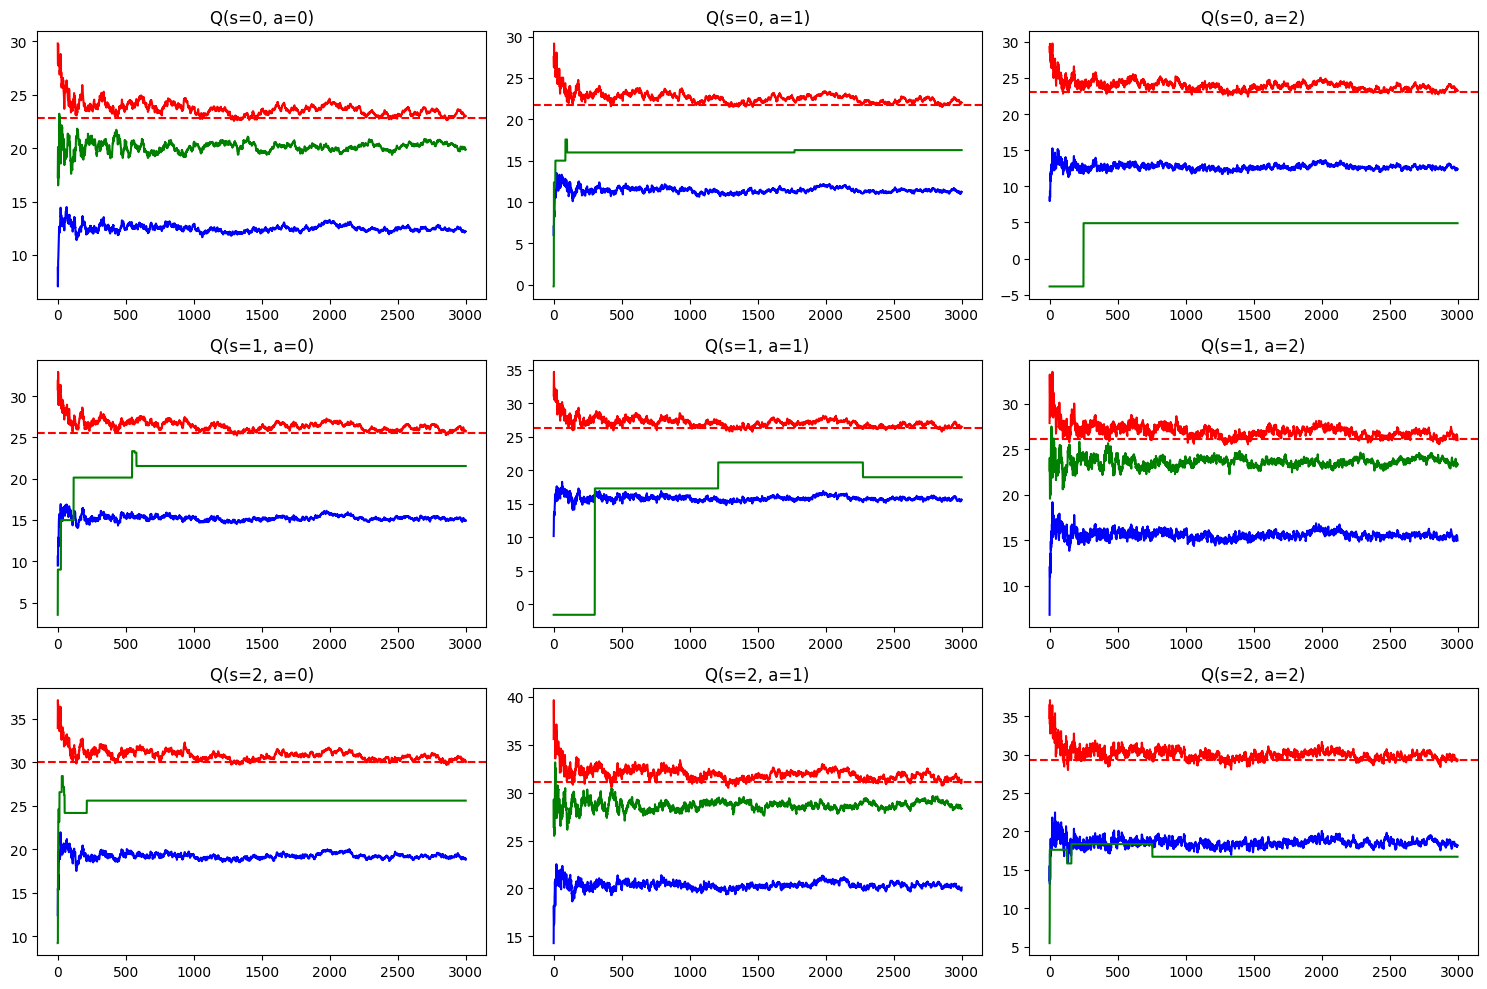

In [ ]:
def ci95(data):
    mean = data.mean(axis=0)
    std = data.std(axis=0, ddof=1)
    se = std/np.sqrt(data.shape[0])
    ci = 1.96*se
    return mean, ci

fig, axes = plt.subplots(3, 3, figsize=(15,10))

for s in range(3):
    for a in range(3):
        ax = axes[s, a]

        q_sarsa = all_seed_Q_table_SARSA[:, :, s, a]
        q_rsarsa = all_seed_Q_table_rSARSA[:, :, s, a]
        q_ql    = all_seed_Q_table_QL[:, :, s, a]

        mean_sarsa, ci_sarsa = ci95(q_sarsa)
        mean_rsarsa, ci_rsarsa = ci95(q_rsarsa)
        mean_ql, ci_ql       = ci95(q_ql)

        x = np.arange(len(mean_sarsa))

        ax.axhline(Q_star[s, a], linestyle="--", label="Q*", color= "red")
        #ax.axhline(Q_bar[s, a], linestyle="--", label="Q-bar", color= "blue")
        
        ax.plot(x, mean_sarsa, color="blue")
        ax.fill_between(x, mean_sarsa-ci_sarsa, mean_sarsa+ci_sarsa, alpha=0.2)

        ax.plot(x, mean_rsarsa, color="green")
        ax.fill_between(x, mean_rsarsa-ci_rsarsa, mean_rsarsa+ci_rsarsa, alpha=0.2)

        ax.plot(x, mean_ql, color="red")
        ax.fill_between(x, mean_ql-ci_ql, mean_ql+ci_ql, alpha=0.2)

        ax.set_title(f"Q(s={s}, a={a})")

plt.tight_layout()
plt.show()

/home/larry/my_rl_project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


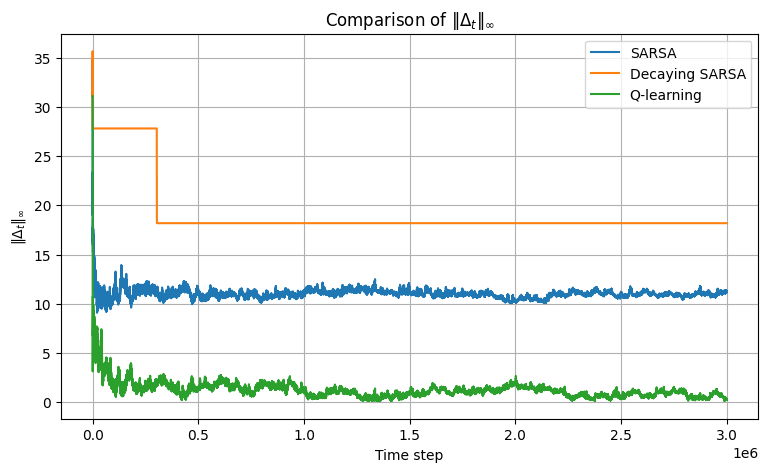

In [ ]:

plt.figure(figsize=(9, 5))

plt.plot(diagnostics_SARSA["delta_norm_history"], label="SARSA")
plt.plot(diagnostics_rSARSA["delta_norm_history"], label="Decaying SARSA")
plt.plot(diagnostics_QL["delta_norm_history"], label="Q-learning")

plt.xlabel("Time step")
plt.ylabel(r"$\|\Delta_t\|_\infty$")
plt.title(r"Comparison of $\|\Delta_t\|_\infty$")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(diagnostics_SARSA["Ct_history"], label="SARSA")
plt.plot(diagnostics_rSARSA["Ct_history"], label="Decaying SARSA")
plt.plot(diagnostics_QL["Ct_history"], label="Q-learning")

plt.xlabel("Time step")
plt.ylabel(r"$C_t$")
plt.title(r"Comparison of Correction Term $C_t$")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'diagnostics_SARSA' is not defined

<Figure size 900x500 with 0 Axes>